# Dynamic Visual Reasoning Benchmark — Minimal Publishable Analysis

This notebook is intentionally compact and comparison-first. It uses the enriched Parquet export from the benchmark task and includes only four outputs:

1. **Total score comparison across models**
2. **Clustered comparison of subtask groups across models**
3. **Distribution of total example-level scores**
4. **Task-complexity analytics**

The notebook expects the enriched schema with component columns such as:

- `score_hit_object`
- `score_visible_objects`
- `score_overlapping_objects`
- `score_layer_groups`
- `score_total` or `result`


## 1. Setup


In [1]:

from __future__ import annotations

import ast
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown

# Global visual style: clean, print-friendly, and high contrast
plt.rcParams.update({
    "figure.dpi": 96,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "legend.frameon": False,
    "legend.fontsize": 10,
})

OUTPUT_DIR = Path("analysis_outputs_minimal")
OUTPUT_DIR.mkdir(exist_ok=True)

# Colorblind-friendly palette
MODEL_PALETTE = [
    "#4E79A7", "#F28E2B", "#59A14F", "#E15759",
    "#76B7B2", "#EDC948", "#B07AA1", "#FF9DA7"
]
SUBTASK_COLORS = {
    "Hit object": "#76B7B2",
    "Visible objects": "#EDC948",
    "Overlapping objects": "#B07AA1",
    "Layer groups": "#FF9DA7",
}
BAR_FILL = "#87CEEB"
BAR_HIGHLIGHT = "#87CEEB"
ERROR_COLOR = "#111111"




## 2. Configure input Parquet files


In [2]:

# Option A: one combined parquet containing all models
COMBINED_PARQUET_PATH = None # "benchmark_run_details.parquet"

# Option B: one parquet per model
PARQUET_FILES = {
    "Gemini 3 Flash Preview": "gemini_3_flash_preview.parquet",
    "Gemini 3.1 Pro Preview": "gemini_3_1_pro_preview.parquet",
    "Qwen 3 235B A22B Instruct": "qwen_3_235b_a22b_instruct.parquet",
    "Claude Opus 4.7": "claude_opus_4_7.parquet",
    "Claude Sonnet 4.6": "claude_sonnet_4_6.parquet",
}




## 3. Helper functions


In [3]:

def _maybe_parse_json_like(value):
    if isinstance(value, (list, dict)):
        return value
    if value is None:
        return None
    if not isinstance(value, str):
        return value

    text = value.strip()
    if not text:
        return None

    for parser in (json.loads, ast.literal_eval):
        try:
            return parser(text)
        except Exception:
            continue
    return value


def normalize_name_list(value) -> list[str]:
    value = _maybe_parse_json_like(value)
    if value is None:
        return []
    if isinstance(value, str):
        return [value] if value else []
    if isinstance(value, (list, tuple, set)):
        return [str(x) for x in value if str(x).strip()]
    return [str(value)]


def normalize_layer_groups(value) -> list[list[str]]:
    value = _maybe_parse_json_like(value)
    if value in (None, ""):
        return []
    if isinstance(value, str):
        value = [value]
    if not isinstance(value, (list, tuple)):
        return []

    groups = []
    for group in value:
        group = _maybe_parse_json_like(group)
        if group is None:
            continue
        if isinstance(group, str):
            items = [group] if group else []
        elif isinstance(group, (list, tuple, set)):
            items = [str(x) for x in group if str(x).strip()]
        else:
            items = [str(group)]
        if items:
            groups.append(items)
    return groups


def flatten_layer_groups(groups: list[list[str]]) -> list[str]:
    return [item for group in groups for item in group]


def bootstrap_mean_ci(values, n_boot=4000, alpha=0.05, seed=42):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    n = len(values)
    boots = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boots[i] = sample.mean()

    mean = values.mean()
    lo = np.quantile(boots, alpha / 2)
    hi = np.quantile(boots, 1 - alpha / 2)
    return mean, lo, hi


def infer_model_name(df: pd.DataFrame, fallback: str) -> str:
    if "model" in df.columns and df["model"].notna().any():
        return str(df["model"].dropna().iloc[0])
    if "llm" in df.columns and df["llm"].notna().any():
        return str(df["llm"].dropna().iloc[0]).replace("🤖 ", "").strip()
    return fallback


def load_details(combined_path: str | None, parquet_files: dict[str, str]) -> pd.DataFrame:
    frames = []

    if combined_path:
        path = Path(combined_path)
        if path.exists():
            df = pd.read_parquet(path).copy()
            if "model" not in df.columns or df["model"].isna().all():
                inferred = infer_model_name(df, fallback=path.stem)
                df["model"] = inferred
            frames.append(df)

    for model_name, file_path in parquet_files.items():
        path = Path(file_path)
        if path.exists():
            df = pd.read_parquet(path).copy()
            df["model"] = model_name
            frames.append(df)

    if not frames:
        raise FileNotFoundError(
            "No parquet files found. Update COMBINED_PARQUET_PATH or PARQUET_FILES."
        )

    details = pd.concat(frames, ignore_index=True)

    if "score_total" in details.columns:
        details["total_score"] = pd.to_numeric(details["score_total"], errors="coerce")
    elif "result" in details.columns:
        details["total_score"] = pd.to_numeric(details["result"], errors="coerce")
    else:
        raise ValueError("Could not find `score_total` or `result` in the parquet data.")

    required_subtasks = [
        "score_hit_object",
        "score_visible_objects",
        "score_overlapping_objects",
        "score_layer_groups",
    ]
    missing = [c for c in required_subtasks if c not in details.columns]
    if missing:
        raise ValueError(f"Missing required enriched component columns: {missing}")

    for col in required_subtasks:
        details[col] = pd.to_numeric(details[col], errors="coerce")

    details["q1_hit_object"] = details["q1_hit_object"].astype(str)
    details["visible_count"] = details["q2_visible_objects"].map(lambda x: len(normalize_name_list(x)))
    details["overlap_count"] = details["q3a_visible_overlapping_objects"].map(lambda x: len(normalize_name_list(x)))
    details["layer_groups_parsed"] = details["q3b_layer_groups_bottom_to_top"].map(normalize_layer_groups)
    details["layer_depth"] = details["layer_groups_parsed"].map(len)
    details["layer_object_count"] = details["layer_groups_parsed"].map(lambda x: len(flatten_layer_groups(x)))
    details["hit_is_wall"] = details["q1_hit_object"].str.lower().eq("wall")

    # Transparent annotation-derived complexity index
    details["complexity_index"] = (
        (~details["hit_is_wall"]).astype(int)
        + details["visible_count"]
        + details["overlap_count"]
        + details["layer_object_count"]
    )

    unique_complexity = details["complexity_index"].nunique()
    if unique_complexity >= 3:
        details["complexity_tier"] = pd.qcut(
            details["complexity_index"],
            q=3,
            labels=["Easy", "Medium", "Hard"],
            duplicates="drop",
        )
    else:
        details["complexity_tier"] = details["complexity_index"].astype(str)

    details["complexity_tier"] = details["complexity_tier"].astype(str)

    return details


def save_figure(fig, stem: str):
    fig.savefig(OUTPUT_DIR / f"{stem}.png", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{stem}.svg", bbox_inches="tight")




## 4. Load data


In [4]:

details = load_details(COMBINED_PARQUET_PATH, PARQUET_FILES).copy()

display(Markdown("### Loaded data preview"))
display(details.head())

display(Markdown(
    f"Loaded **{len(details):,}** example rows across **{details['model'].nunique()}** model(s)."
))




### Loaded data preview

,llm,prompt,image_path,q1_hit_object,q2_visible_objects,q3a_visible_overlapping_objects,q3b_layer_groups_bottom_to_top,pred_hit_object,pred_visible_objects_at_that_moment,pred_visible_overlapping_objects,...,prediction_error,total_score,visible_count,overlap_count,layer_groups_parsed,layer_depth,layer_object_count,hit_is_wall,complexity_index,complexity_tier
0,🤖 google/gemini-3-flash-preview,You are playing the special billiard game. Ini...,/kaggle/input/datasets/akaliutau/dynavisr/imag...,Wall,[],[],[],Wall,[],[],...,NaN,1.0,0,0,[],0,0,True,0,Easy
1,🤖 google/gemini-3-flash-preview,You are playing the special billiard game. Ini...,/kaggle/input/datasets/akaliutau/dynavisr/imag...,Wall,[],[],[],A,[],[],...,NaN,0.6,0,0,[],0,0,True,0,Easy
2,🤖 google/gemini-3-flash-preview,You are playing the special billiard game. Ini...,/kaggle/input/datasets/akaliutau/dynavisr/imag...,C,"[""C""]",[],[],C,"[""C""]",[],...,NaN,1.0,1,0,[],0,0,False,2,Medium
3,🤖 google/gemini-3-flash-preview,You are playing the special billiard game. Ini...,/kaggle/input/datasets/akaliutau/dynavisr/imag...,D,"[""D""]",[],[],D,"[""D""]",[],...,NaN,1.0,1,0,[],0,0,False,2,Medium
4,🤖 google/gemini-3-flash-preview,You are playing the special billiard game. Ini...,/kaggle/input/datasets/akaliutau/dynavisr/imag...,Wall,[],[],[],Wall,[],[],...,NaN,1.0,0,0,[],0,0,True,0,Easy


Loaded **500** example rows across **5** model(s).

## 5. Summary tables used by the figures


In [5]:

# Total-score summary with bootstrap confidence intervals
summary_rows = []
for model_name, g in details.groupby("model"):
    mean_score, ci_low, ci_high = bootstrap_mean_ci(g["total_score"].values)
    summary_rows.append({
        "model": model_name,
        "n_examples": len(g),
        "mean_total_score": mean_score,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "median_total_score": g["total_score"].median(),
        "std_total_score": g["total_score"].std(ddof=1),
    })

model_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("mean_total_score", ascending=False)
    .reset_index(drop=True)
)

display(Markdown("### Model summary"))
display(model_summary)

# Subtask-group summary
subtask_map = {
    "score_hit_object": "Hit object",
    "score_visible_objects": "Visible objects",
    "score_overlapping_objects": "Overlapping objects",
    "score_layer_groups": "Layer groups",
}

subtask_rows = []
for model_name, g in details.groupby("model"):
    for col, label in subtask_map.items():
        mean_score, ci_low, ci_high = bootstrap_mean_ci(g[col].values)
        subtask_rows.append({
            "model": model_name,
            "subtask": label,
            "mean_score": mean_score,
            "ci_low": ci_low,
            "ci_high": ci_high,
        })

subtask_summary = pd.DataFrame(subtask_rows)

# Complexity summary
complexity_summary = (
    details.groupby(["complexity_tier"], dropna=False)
    .agg(
        n_examples=("total_score", "size"),
        mean_complexity_index=("complexity_index", "mean"),
        mean_visible_count=("visible_count", "mean"),
        mean_overlap_count=("overlap_count", "mean"),
        mean_layer_object_count=("layer_object_count", "mean"),
    )
    .reset_index()
)

display(Markdown("### Complexity tier summary"))
display(complexity_summary)




### Model summary

,model,n_examples,mean_total_score,ci_low,ci_high,median_total_score,std_total_score
0,Gemini 3.1 Pro Preview,100,0.8980,0.8590,0.934000,1.000,0.192002
1,Gemini 3 Flash Preview,100,0.7585,0.6985,0.814500,1.000,0.297299
2,Qwen 3 235B A22B Instruct,100,0.6010,0.5455,0.657013,0.600,0.279428
3,Claude Sonnet 4.6,100,0.5830,0.5135,0.649013,0.600,0.340693
4,Claude Opus 4.7,100,0.4120,0.3460,0.476000,0.375,0.337633


### Complexity tier summary

,complexity_tier,n_examples,mean_complexity_index,mean_visible_count,mean_overlap_count,mean_layer_object_count
0,Easy,275,0.527273,0.527273,0.000000,0.000000
1,Hard,165,6.666667,2.363636,1.787879,1.787879
2,Medium,60,2.000000,1.416667,0.000000,0.000000


## 6. Figure 1 — Total score comparison


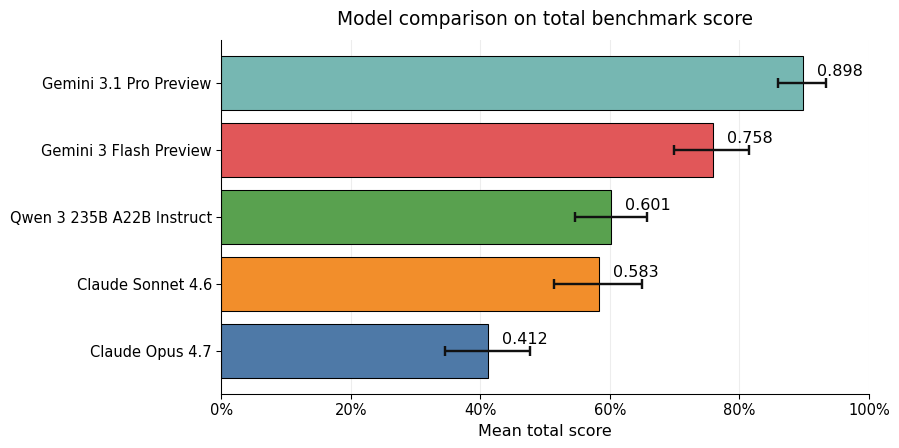

In [6]:
plot_df = model_summary.sort_values("mean_total_score", ascending=True).reset_index(drop=True)
x = plot_df["mean_total_score"].values
y = np.arange(len(plot_df))
xerr = np.vstack([
    x - plot_df["ci_low"].values,
    plot_df["ci_high"].values - x,
])

fig, ax = plt.subplots(figsize=(9.5, 4.8))

colors = MODEL_PALETTE

bars = ax.barh(
    plot_df["model"],
    x,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=2,
)

ax.errorbar(
    x,
    y,
    xerr=xerr,
    fmt="none",
    ecolor=ERROR_COLOR,
    elinewidth=1.8,
    capsize=4,
    capthick=1.8,
    zorder=3,
)

for yi, xi in zip(y, x):
    ax.text(
        xi + 0.022,
        yi + 0.06,
        f"{xi:.3f}",
        va="bottom",
        ha="left",
        fontsize=12,
    )

ax.set_title("Model comparison on total benchmark score", pad=12)
ax.set_xlabel("Mean total score")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xlim(0, min(1.0, max(0.05, plot_df["ci_high"].max() * 1.15)))
ax.grid(axis="x", alpha=0.22, zorder=1)

plt.tight_layout()
save_figure(fig, "figure_1_total_score_comparison")
plt.show()

## 7. Figure 2 — Clustered comparison of subtask groups


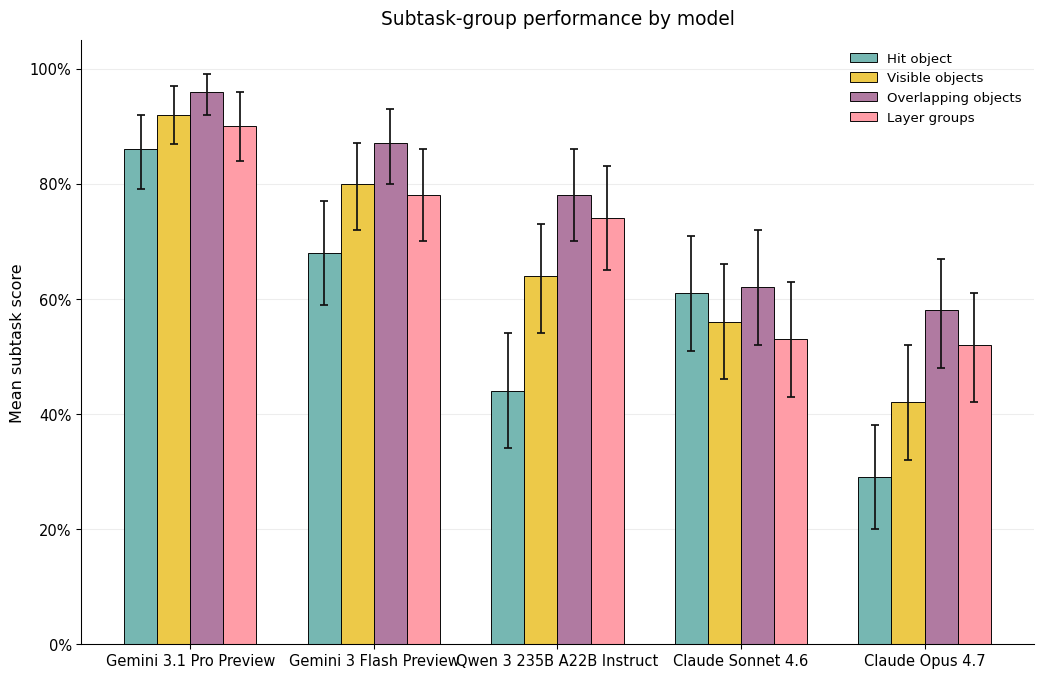

In [7]:

model_order = model_summary["model"].tolist()
subtask_order = list(subtask_map.values())

plot_sub = subtask_summary.copy()
plot_sub["model"] = pd.Categorical(plot_sub["model"], categories=model_order, ordered=True)
plot_sub["subtask"] = pd.Categorical(plot_sub["subtask"], categories=subtask_order, ordered=True)
plot_sub = plot_sub.sort_values(["model", "subtask"]).reset_index(drop=True)

x = np.arange(len(model_order))
width = 0.18
offsets = np.linspace(-1.5 * width, 1.5 * width, len(subtask_order))

fig, ax = plt.subplots(figsize=(11.0, 7.2))

for offset, subtask in zip(offsets, subtask_order):
    g = plot_sub[plot_sub["subtask"] == subtask].set_index("model").loc[model_order].reset_index()
    means = g["mean_score"].values
    lower = means - g["ci_low"].values
    upper = g["ci_high"].values - means

    ax.bar(
        x + offset,
        means,
        width=width,
        label=subtask,
        color=SUBTASK_COLORS[subtask],
        edgecolor="black",
        linewidth=0.7,
        zorder=2,
    )
    ax.errorbar(
        x + offset,
        means,
        yerr=np.vstack([lower, upper]),
        fmt="none",
        ecolor=ERROR_COLOR,
        elinewidth=1.3,
        capsize=3,
        capthick=1.3,
        zorder=3,
    )

ax.set_title("Subtask-group performance by model", pad=12)
ax.set_ylabel("Mean subtask score")
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=0, ha="center")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.grid(axis="y", alpha=0.22, zorder=1)
ax.legend(ncols=1, loc="upper right")

plt.tight_layout()
save_figure(fig, "figure_2_subtask_group_comparison")
plt.show()




## 8. Figure 3 — Distribution of total example-level scores


/tmp/ipykernel_20966/2650304623.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


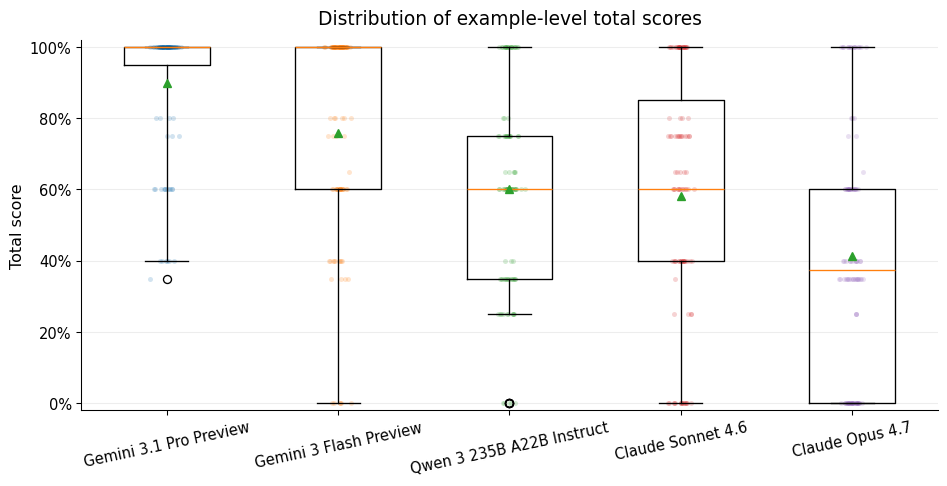

In [8]:

dist_df = details.copy()
dist_df["model"] = pd.Categorical(dist_df["model"], categories=model_order, ordered=True)
dist_df = dist_df.sort_values("model")

grouped_values = [
    dist_df.loc[dist_df["model"] == model_name, "total_score"].dropna().to_numpy(dtype=float)
    for model_name in model_order
]

fig, ax = plt.subplots(figsize=(10.0, 5.2))

ax.boxplot(
    grouped_values,
    vert=True,
    patch_artist=False,
    labels=model_order,
    showmeans=True,
    meanline=False,
    whis=(5, 95),
)

for i, values in enumerate(grouped_values, start=1):
    rng = np.random.default_rng(42 + i)
    jitter = rng.normal(0, 0.035, size=len(values))
    ax.scatter(
        np.full(len(values), i) + jitter,
        values,
        alpha=0.20,
        s=14,
        linewidths=0,
    )

ax.set_title("Distribution of example-level total scores", pad=12)
ax.set_ylabel("Total score")
ax.set_ylim(-0.02, 1.02)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.grid(axis="y", alpha=0.22)
ax.tick_params(axis="x", rotation=12)

plt.tight_layout()
save_figure(fig, "figure_3_total_score_distribution")
plt.show()




## 10. Export compact tables


In [9]:

model_summary.to_csv(OUTPUT_DIR / "model_summary.csv", index=False)
subtask_summary.to_csv(OUTPUT_DIR / "subtask_summary.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR.resolve())
for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path.name)




Saved outputs to: /content/analysis_outputs_minimal
- figure_1_total_score_comparison.pdf
- figure_1_total_score_comparison.png
- figure_1_total_score_comparison.svg
- figure_2_subtask_group_comparison.pdf
- figure_2_subtask_group_comparison.png
- figure_2_subtask_group_comparison.svg
- figure_3_total_score_distribution.pdf
- figure_3_total_score_distribution.png
- figure_3_total_score_distribution.svg
- model_summary.csv
- subtask_summary.csv


## 11. Ready-to-use interpretation text


In [10]:

best = model_summary.iloc[0]
worst = model_summary.iloc[-1]
spread = best["mean_total_score"] - worst["mean_total_score"]

summary_text = f'''
### Concise write-up

- **Best overall model:** {best["model"]} with mean total score **{best["mean_total_score"]:.3f}**
  (95% CI: **{best["ci_low"]:.3f}–{best["ci_high"]:.3f}**).
- **Performance spread across models:** **{spread:.3f}** total-score points.
- The clustered subtask view shows where systems separate most strongly across
  hit prediction, visibility reasoning, overlap reasoning, and layer-group reasoning.
- The total-score distribution plot shows whether gains come from consistent improvements
  across examples or only from a subset of cases.
- The complexity analysis shows how performance changes from easier to harder,
  annotation-defined scenarios.

This notebook intentionally keeps the analysis minimal and comparison-oriented.
'''
display(Markdown(summary_text))




### Concise write-up

- **Best overall model:** Gemini 3.1 Pro Preview with mean total score **0.898**
  (95% CI: **0.859–0.934**).
- **Performance spread across models:** **0.486** total-score points.
- The clustered subtask view shows where systems separate most strongly across
  hit prediction, visibility reasoning, overlap reasoning, and layer-group reasoning.
- The total-score distribution plot shows whether gains come from consistent improvements
  across examples or only from a subset of cases.
- The complexity analysis shows how performance changes from easier to harder,
  annotation-defined scenarios.

This notebook intentionally keeps the analysis minimal and comparison-oriented.
